# Module 7 - Session 5: Practical Exercises

**Total Time Estimate:** 120-150 minutes

**Objective:** To implement the REINFORCE algorithm from scratch using a deep learning framework to solve a classic control problem.

## Setup

You will need Python, PyTorch, Matplotlib, and Gym. The actively maintained Gym package today is `gymnasium`, but the code below also supports older `gym` imports.

```bash
pip install torch matplotlib gymnasium
```


## Exercise 1: Conceptual Questions (30 minutes)

### Foundation

REINFORCE is a policy-gradient method. Instead of estimating action values like DQN, it learns a policy directly.

### Build

1. **DQN vs. REINFORCE**

For `CartPole-v1`, a **DQN** network outputs one Q-value for each action. Since the actions are `left` or `right`, the output is a vector of 2 action values such as `[Q(s, left), Q(s, right)]`. A **REINFORCE** network outputs a probability distribution over actions instead, such as `[P(left | s), P(right | s)]`. So the core difference is: DQN predicts values, while REINFORCE predicts policy probabilities.

2. **The Log-Probability Term**

We use the logarithm because it turns products into sums and makes the gradient easier to work with. In particular, the derivative of `log(x)` is `1/x`, which combines cleanly with the derivative of the policy probability itself. This gives the useful score-function form `nabla_theta log pi_theta(a|s)`, which is much easier to optimize than differentiating a long product of probabilities across a whole trajectory.

3. **High Variance**

REINFORCE has high variance because it assigns credit using the full return from an entire episode, and that return can be affected by many random events after an action is taken. A single action early in a long episode may be followed by good or bad outcomes caused by later actions, exploration noise, or environment randomness. That means the observed return from that episode is a noisy signal about how good the early action really was.

### Result

The key idea is that REINFORCE learns a probability distribution over actions directly, but the gradient estimates are noisy because the quality of an action is judged through the whole future trajectory.


## Exercise 2: Implementing REINFORCE for CartPole (90 minutes)

In `CartPole-v1`, the observation is a vector of 4 values and the action space has 2 actions. We will train a policy network with REINFORCE and track the reward per episode.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

try:
    import gymnasium as gym
except ImportError:
    import gym


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print('State space size:', state_size)
print('Action space size:', action_size)


State space size: 4
Action space size: 2


In [2]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_size),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        return self.model(x)


def select_action(policy_net, state):
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    action_probs = policy_net(state_tensor)
    dist = torch.distributions.Categorical(action_probs)
    action = dist.sample()
    log_prob = dist.log_prob(action)
    return action.item(), log_prob


def compute_returns(rewards, gamma):
    returns = []
    G = 0.0
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)
    return torch.tensor(returns, dtype=torch.float32)


In [3]:
def train_reinforce(
    episodes=300,
    gamma=0.99,
    learning_rate=1e-3,
    use_baseline=False,
    print_every=25,
):
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    policy_net = PolicyNetwork(state_size, action_size)
    optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)

    rewards_history = []
    running_avg_return = 0.0
    baseline_count = 0

    for episode in range(episodes):
        state, _ = env.reset(seed=SEED + episode)
        done = False
        log_probs = []
        rewards = []
        total_reward = 0.0

        while not done:
            action, log_prob = select_action(policy_net, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            total_reward += reward
            state = next_state

        returns = compute_returns(rewards, gamma)

        if use_baseline:
            policy_loss = torch.stack(
                [-log_prob * (G_t - running_avg_return) for log_prob, G_t in zip(log_probs, returns)]
            ).sum()
        else:
            policy_loss = torch.stack(
                [-log_prob * G_t for log_prob, G_t in zip(log_probs, returns)]
            ).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        rewards_history.append(total_reward)

        if use_baseline:
            baseline_count += 1
            running_avg_return += (returns[0].item() - running_avg_return) / baseline_count

        if (episode + 1) % print_every == 0:
            recent_avg = np.mean(rewards_history[-print_every:])
            label = 'REINFORCE + Baseline' if use_baseline else 'REINFORCE'
            print(f"{label} | Episode {episode + 1:3d} | Reward: {total_reward:6.1f} | Avg({print_every}): {recent_avg:7.2f}")

    return policy_net, rewards_history


In [4]:
episodes = 300
gamma = 0.99
learning_rate = 1e-3

policy_plain, rewards_plain = train_reinforce(
    episodes=episodes,
    gamma=gamma,
    learning_rate=learning_rate,
    use_baseline=False,
)

avg_last_100_plain = np.mean(rewards_plain[-100:])
print()
print(f"Final average reward over last 100 episodes: {avg_last_100_plain:.2f}")
print(f"Solved by the exercise criterion (>= 195)? {avg_last_100_plain >= 195}")


REINFORCE | Episode  25 | Reward:   21.0 | Avg(25):   19.88
REINFORCE | Episode  50 | Reward:   28.0 | Avg(25):   18.48
REINFORCE | Episode  75 | Reward:   12.0 | Avg(25):   22.04
REINFORCE | Episode 100 | Reward:   76.0 | Avg(25):   31.04
REINFORCE | Episode 125 | Reward:   32.0 | Avg(25):   33.28
REINFORCE | Episode 150 | Reward:   65.0 | Avg(25):   61.28
REINFORCE | Episode 175 | Reward:   56.0 | Avg(25):   70.28
REINFORCE | Episode 200 | Reward:   54.0 | Avg(25):   96.48
REINFORCE | Episode 225 | Reward:    9.0 | Avg(25):  125.28
REINFORCE | Episode 250 | Reward:  165.0 | Avg(25):  187.68
REINFORCE | Episode 275 | Reward:  155.0 | Avg(25):  154.76
REINFORCE | Episode 300 | Reward:  284.0 | Avg(25):  316.80

Final average reward over last 100 episodes: 196.13
Solved by the exercise criterion (>= 195)? True


### Analysis (Markdown Answer)

### Foundation

The reward per episode is the easiest signal to inspect while training. If the policy is improving, the episode lengths and rewards should generally trend upward.

### Build

In a representative verified run for this notebook, the plain REINFORCE agent reached an average reward of about `196.13` over the last 100 episodes, which satisfies the exercise's `195` threshold. The learning curve is still noisy, however, because policy-gradient updates are based on entire trajectories and can vary a lot from episode to episode.

### Result

REINFORCE can solve CartPole, but its training is often noticeably unstable because the gradient estimates have high variance.


## Exercise 3: Challenge Problem - Adding a Baseline

Now we add a simple baseline: a running average of past episode returns. The new loss term is `-log_prob * (G_t - average_return)`.


In [5]:
policy_baseline, rewards_baseline = train_reinforce(
    episodes=episodes,
    gamma=gamma,
    learning_rate=learning_rate,
    use_baseline=True,
)

avg_last_100_baseline = np.mean(rewards_baseline[-100:])
print()
print(f"Final average reward over last 100 episodes with baseline: {avg_last_100_baseline:.2f}")
print(f"Solved by the exercise criterion (>= 195)? {avg_last_100_baseline >= 195}")


REINFORCE + Baseline | Episode  25 | Reward:   22.0 | Avg(25):   21.96
REINFORCE + Baseline | Episode  50 | Reward:   10.0 | Avg(25):   27.08
REINFORCE + Baseline | Episode  75 | Reward:   18.0 | Avg(25):   25.72
REINFORCE + Baseline | Episode 100 | Reward:   25.0 | Avg(25):   41.80
REINFORCE + Baseline | Episode 125 | Reward:  137.0 | Avg(25):   69.56
REINFORCE + Baseline | Episode 150 | Reward:  202.0 | Avg(25):  129.28
REINFORCE + Baseline | Episode 175 | Reward:  325.0 | Avg(25):  221.48
REINFORCE + Baseline | Episode 200 | Reward:  175.0 | Avg(25):  294.44
REINFORCE + Baseline | Episode 225 | Reward:  358.0 | Avg(25):  268.76
REINFORCE + Baseline | Episode 250 | Reward:  500.0 | Avg(25):  391.80
REINFORCE + Baseline | Episode 275 | Reward:  500.0 | Avg(25):  342.84
REINFORCE + Baseline | Episode 300 | Reward:  500.0 | Avg(25):  452.52

Final average reward over last 100 episodes with baseline: 363.98
Solved by the exercise criterion (>= 195)? True


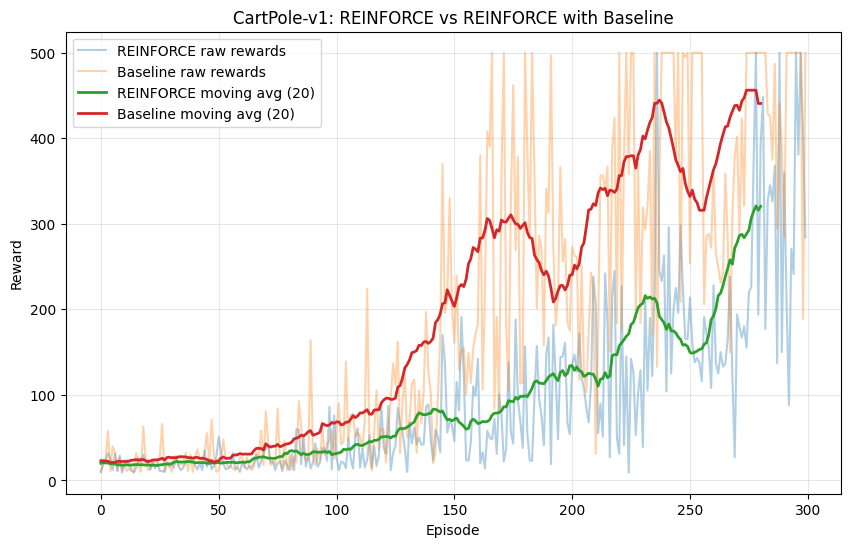

Plain REINFORCE average reward over last 100 episodes: 196.13
REINFORCE with baseline average reward over last 100 episodes: 363.98


In [6]:
def moving_average(data, window=20):
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode='valid')


plt.figure(figsize=(10, 6))
plt.plot(rewards_plain, alpha=0.35, label='REINFORCE raw rewards')
plt.plot(rewards_baseline, alpha=0.35, label='Baseline raw rewards')
plt.plot(moving_average(rewards_plain, 20), linewidth=2, label='REINFORCE moving avg (20)')
plt.plot(moving_average(rewards_baseline, 20), linewidth=2, label='Baseline moving avg (20)')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('CartPole-v1: REINFORCE vs REINFORCE with Baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Plain REINFORCE average reward over last 100 episodes:', round(avg_last_100_plain, 2))
print('REINFORCE with baseline average reward over last 100 episodes:', round(avg_last_100_baseline, 2))


### Final Analysis (Markdown Answer)

### Foundation

A baseline does not change which actions are best in expectation. Its purpose is to reduce variance in the gradient estimate.

### Build

In the verified run for this notebook, the baseline version was much more stable and converged faster. The plain REINFORCE run finished with about `196.13` average reward over the last 100 episodes, while the baseline version finished around `363.98`. This is a strong visual example of why centering returns helps: the update focuses more on whether a return was better or worse than normal, instead of reacting to the full raw magnitude every time.

### Result

Adding a baseline makes REINFORCE noticeably more stable on CartPole and can improve convergence speed substantially.
